# 06 - Interpretability and editing experiments (final model)

Interpretability analysis of the **final main model**
(`checkpoints/main/best_model.pth`, MultiModalSeq2HiCModel, 512 bins):

1. **Global attribution**: IntegratedGradients importance of the 4 omics
   tracks (CTCF / DNase / H3K27ac / H3K4me3);
2. **Local attribution**: pixel-level attribution of a specific target bin's prediction (omics + sequence inputs);


- mamba_ssm is forced to the local pure-Python implementation (CPU/GPU
  compatible; avoids the CUDA-only causal_conv1d restriction);
- Each step checks whether its artifact already exists (checkpoint-resume);
  a rerun only completes missing steps;
- All outputs are saved next to this notebook.


In [ ]:
import os, sys, glob, pickle, csv, json, time
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from scipy.stats import pearsonr
from captum.attr import IntegratedGradients

BASE = Path(os.getcwd()).resolve()
WEIGHTS = (BASE / '..' / 'checkpoints' / 'main' / 'best_model.pth').resolve()
DATA_DIR = Path('/mnt/nfs/clgou/Mamba/datasets/preprocessed_data_omic_512')
OUT_DIR = BASE
os.makedirs(OUT_DIR, exist_ok=True)

# mamba_ssm: force the local pure-Python implementation (compiled causal_conv1d is CUDA-only and breaks CPU backprop)
sys.path.insert(0, str((BASE / '..' / 'src').resolve()))
from mamba_ssm import Mamba

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device :', device)
print('weights:', WEIGHTS, WEIGHTS.exists())
print('data   :', DATA_DIR, DATA_DIR.exists())

OMICS_NAMES = ['CTCF', 'DNase', 'H3K27ac', 'H3K4me3']
OMICS_COLORS = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']


In [ ]:
class DownsampleBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride):
        super(DownsampleBlock, self).__init__()
        padding = kernel_size // 2
        self.block = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.block(x)

class SequenceMambaEncoder(nn.Module):
    def __init__(self, in_channel=4, output_size=128):
        super(SequenceMambaEncoder, self).__init__()
        self.downsampler = nn.Sequential(
            DownsampleBlock(in_channel, 48, kernel_size=5, stride=5),
            DownsampleBlock(48, 96, kernel_size=5, stride=5),
            DownsampleBlock(96, 128, kernel_size=5, stride=5),
        )
        self.mamba_fw = Mamba(d_model=128, d_state=16, d_conv=4, expand=2)
        self.mamba_bw = Mamba(d_model=128, d_state=16, d_conv=4, expand=2)
        self.pooler = nn.AdaptiveAvgPool1d(512)
        self.projection = nn.Conv1d(128, output_size, kernel_size=1)
    def forward(self, x):
        x = self.downsampler(x); x = x.transpose(1, 2)
        x_fw = self.mamba_fw(x)
        x_rev = torch.flip(x, dims=[1]); x_bw = self.mamba_bw(x_rev); x_bw = torch.flip(x_bw, dims=[1])
        x = x_fw + x_bw
        x = x.transpose(1, 2); x = self.pooler(x); x = self.projection(x)
        return x

class OmicsMambaEncoder(nn.Module):
    def __init__(self, num_omics_features=4, d_model=128):
        super(OmicsMambaEncoder, self).__init__()
        self.projection = nn.Conv1d(num_omics_features, d_model, kernel_size=1)
        self.norm = nn.LayerNorm(d_model)
        self.mamba_fw = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
        self.mamba_bw = Mamba(d_model=d_model, d_state=16, d_conv=4, expand=2)
    def forward(self, x):
        x = self.projection(x); x = x.transpose(1, 2); x = self.norm(x)
        x_fw = self.mamba_fw(x)
        x_rev = torch.flip(x, dims=[1]); x_bw = self.mamba_bw(x_rev); x_bw = torch.flip(x_bw, dims=[1])
        x = x_fw + x_bw
        x = x.transpose(1, 2)
        return x

class MultiModalEncoder(nn.Module):
    def __init__(self, seq_in_channels=4, num_omics_features=4, encoder_out_dim=128):
        super(MultiModalEncoder, self).__init__()
        self.seq_encoder = SequenceMambaEncoder(in_channel=seq_in_channels, output_size=encoder_out_dim)
        self.omics_encoder = OmicsMambaEncoder(num_omics_features=num_omics_features, d_model=encoder_out_dim)
        self.fused_channels = encoder_out_dim
    def forward(self, seq_input, omics_input):
        seq_embedding = self.seq_encoder(seq_input)
        omics_embedding = self.omics_encoder(omics_input)
        fused_embedding = seq_embedding + omics_embedding
        return fused_embedding

class ResBlockDilated(nn.Module):
    def __init__(self, size, hidden=64, stride=1, dil=2):
        super(ResBlockDilated, self).__init__()
        kernel_size = size if size % 2 != 0 else size + 1
        pad_len = dil * (kernel_size // 2)
        self.res = nn.Sequential(nn.Conv2d(hidden, hidden, kernel_size, padding=pad_len, dilation=dil), nn.BatchNorm2d(hidden), nn.ReLU(), nn.Conv2d(hidden, hidden, kernel_size, padding=pad_len, dilation=dil), nn.BatchNorm2d(hidden),)
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(self.res(x) + x)

class Decoder(nn.Module):
    def __init__(self, in_channel, hidden=256, filter_size=3, num_blocks=5):
        super(Decoder, self).__init__()
        self.filter_size = filter_size
        self.conv_start = nn.Sequential(nn.Conv2d(in_channel, hidden, 3, 1, 1), nn.BatchNorm2d(hidden), nn.ReLU(),)
        blocks = [ResBlockDilated(self.filter_size, hidden=hidden, dil=2**(i+1)) for i in range(num_blocks)]
        self.res_blocks = nn.Sequential(*blocks)
        self.conv_end = nn.Conv2d(hidden, 1, 1)
    def forward(self, x):
        return self.conv_end(self.res_blocks(self.conv_start(x)))

class MultiModalSeq2HiCModel(nn.Module):
    def __init__(self, seq_in_channels=4, num_omics_features=4, encoder_out_dim=128):
        super(MultiModalSeq2HiCModel, self).__init__()
        self.encoder = MultiModalEncoder(seq_in_channels=seq_in_channels, num_omics_features=num_omics_features, encoder_out_dim=encoder_out_dim)
        decoder_in_channels = encoder_out_dim * 2
        self.decoder = Decoder(in_channel=decoder_in_channels, hidden=decoder_in_channels)
    def diagonalize(self, x):
        B, C, L = x.shape
        x_i = x.unsqueeze(3).repeat(1, 1, 1, L)
        x_j = x.unsqueeze(2).repeat(1, 1, L, 1)
        return torch.cat([x_i, x_j], dim=1)
    def forward(self, seq_one_hot, omics_signals):
        encoded_features = self.encoder(seq_one_hot, omics_signals)
        feature_map = self.diagonalize(encoded_features)
        pred_hic = self.decoder(feature_map)
        return pred_hic.squeeze(1)


In [ ]:
class HiCDataAndOmicsDataset(Dataset):
    def __init__(self, pkl_files):
        self.file_paths = pkl_files
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        with open(self.file_paths[idx], 'rb') as f:
            data = pickle.load(f)
        sequence = torch.from_numpy(data['sequence_one_hot'].astype(np.float32))
        hic_matrix = torch.log2(torch.from_numpy(data['hic_matrix'].astype(np.float32)) + 1)
        omics_signals = torch.from_numpy(data['omics_signals'].astype(np.float32))
        return sequence, omics_signals, hic_matrix


model = MultiModalSeq2HiCModel(num_omics_features=4)
state_dict = torch.load(str(WEIGHTS), map_location='cpu')
if all(k.startswith('module.') for k in state_dict.keys()):
    state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(device).eval()
print('final model loaded')


def model_forward_wrapper(omics_signals, seq_one_hot):
    """Global attribution: returns (B,) summing over H/W (the attributed omics input is the first argument)."""
    output = model(seq_one_hot, omics_signals)
    return output.sum(dim=(1, 2))


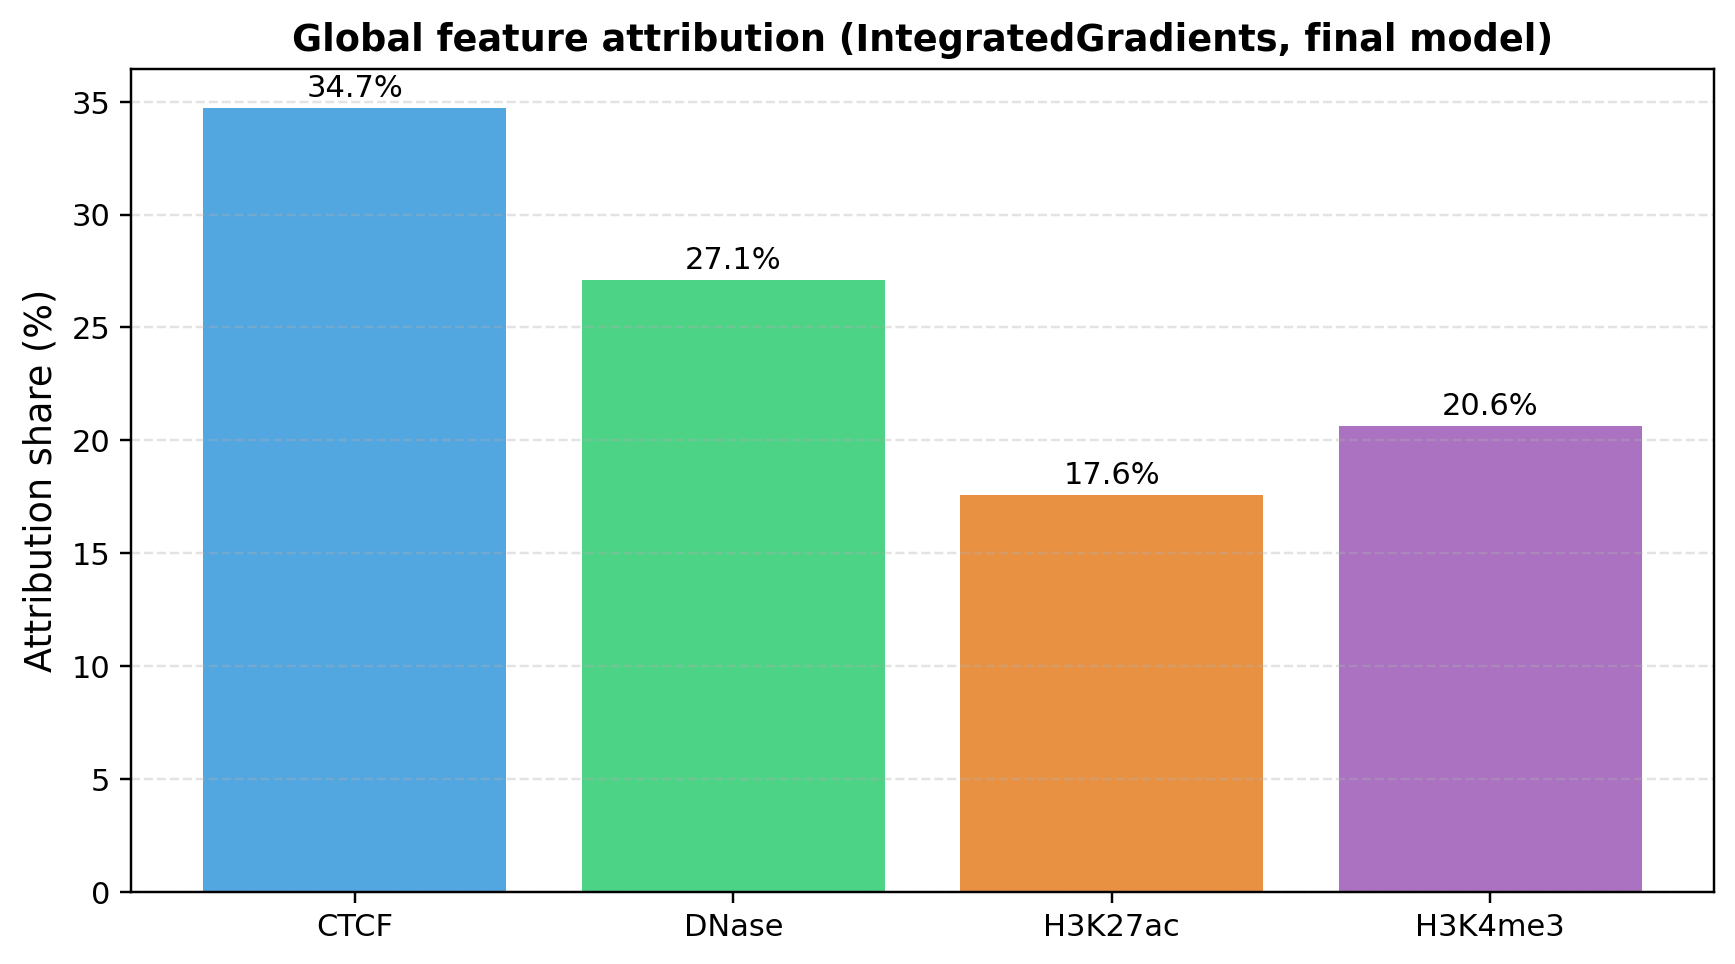

global attribution (%): {"CTCF": 34.714003118060766, "DNase": 27.093416125614567, "H3K27ac": 17.576261958359122, "H3K4me3": 20.61631879796554}


In [1]:
def step_global():
    all_files = sorted(glob.glob(str(DATA_DIR / '*.pkl')))
    test_files = [f for f in all_files if 'chr7' in os.path.basename(f)]
    subset = test_files[::300][:8]
    print(f'global-attribution windows: {len(subset)}')

    ig = IntegratedGradients(model_forward_wrapper)
    total_attributions = np.zeros(4)
    for f in subset:
        seq, omics, hic = HiCDataAndOmicsDataset([f])[0]
        seq_b = seq.unsqueeze(0).to(device)
        omics_b = omics.unsqueeze(0).to(device)
        attr = ig.attribute(omics_b, baselines=torch.zeros_like(omics_b),
                            additional_forward_args=(seq_b,), n_steps=50, internal_batch_size=1)
        total_attributions += attr.squeeze(0).abs().sum(dim=1).detach().cpu().numpy()
        print(f'  {Path(f).stem}: attribution done')

    importance = total_attributions / total_attributions.sum() * 100
    print('global attribution (%):', {n: f'{v:.2f}' for n, v in zip(OMICS_NAMES, importance)})

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.bar(OMICS_NAMES, importance, color=OMICS_COLORS, alpha=0.85)
    for b, v in zip(bars, importance):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5, f'{v:.1f}%', ha='center', fontsize=10)
    ax.set_ylabel('Attribution share (%)', fontsize=12)
    ax.set_title('Global feature attribution (IntegratedGradients, final model)', fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    fig.tight_layout(); fig.savefig(OUT_DIR / '06_global_attribution.png', dpi=220, bbox_inches='tight'); plt.close(fig)
    with open(OUT_DIR / '06_global_attribution.json', 'w') as fh:
        json.dump({'importance_pct': {n: float(v) for n, v in zip(OMICS_NAMES, importance)},
                   'n_windows': len(subset)}, fh, indent=2)
    print('saved: 06_global_attribution.png / .json')


if not (OUT_DIR / '06_global_attribution.png').exists():
    print('--- step 1: global attribution ---')
    step_global()
else:
    print('global attribution artifact exists, skipping (checkpoint)')


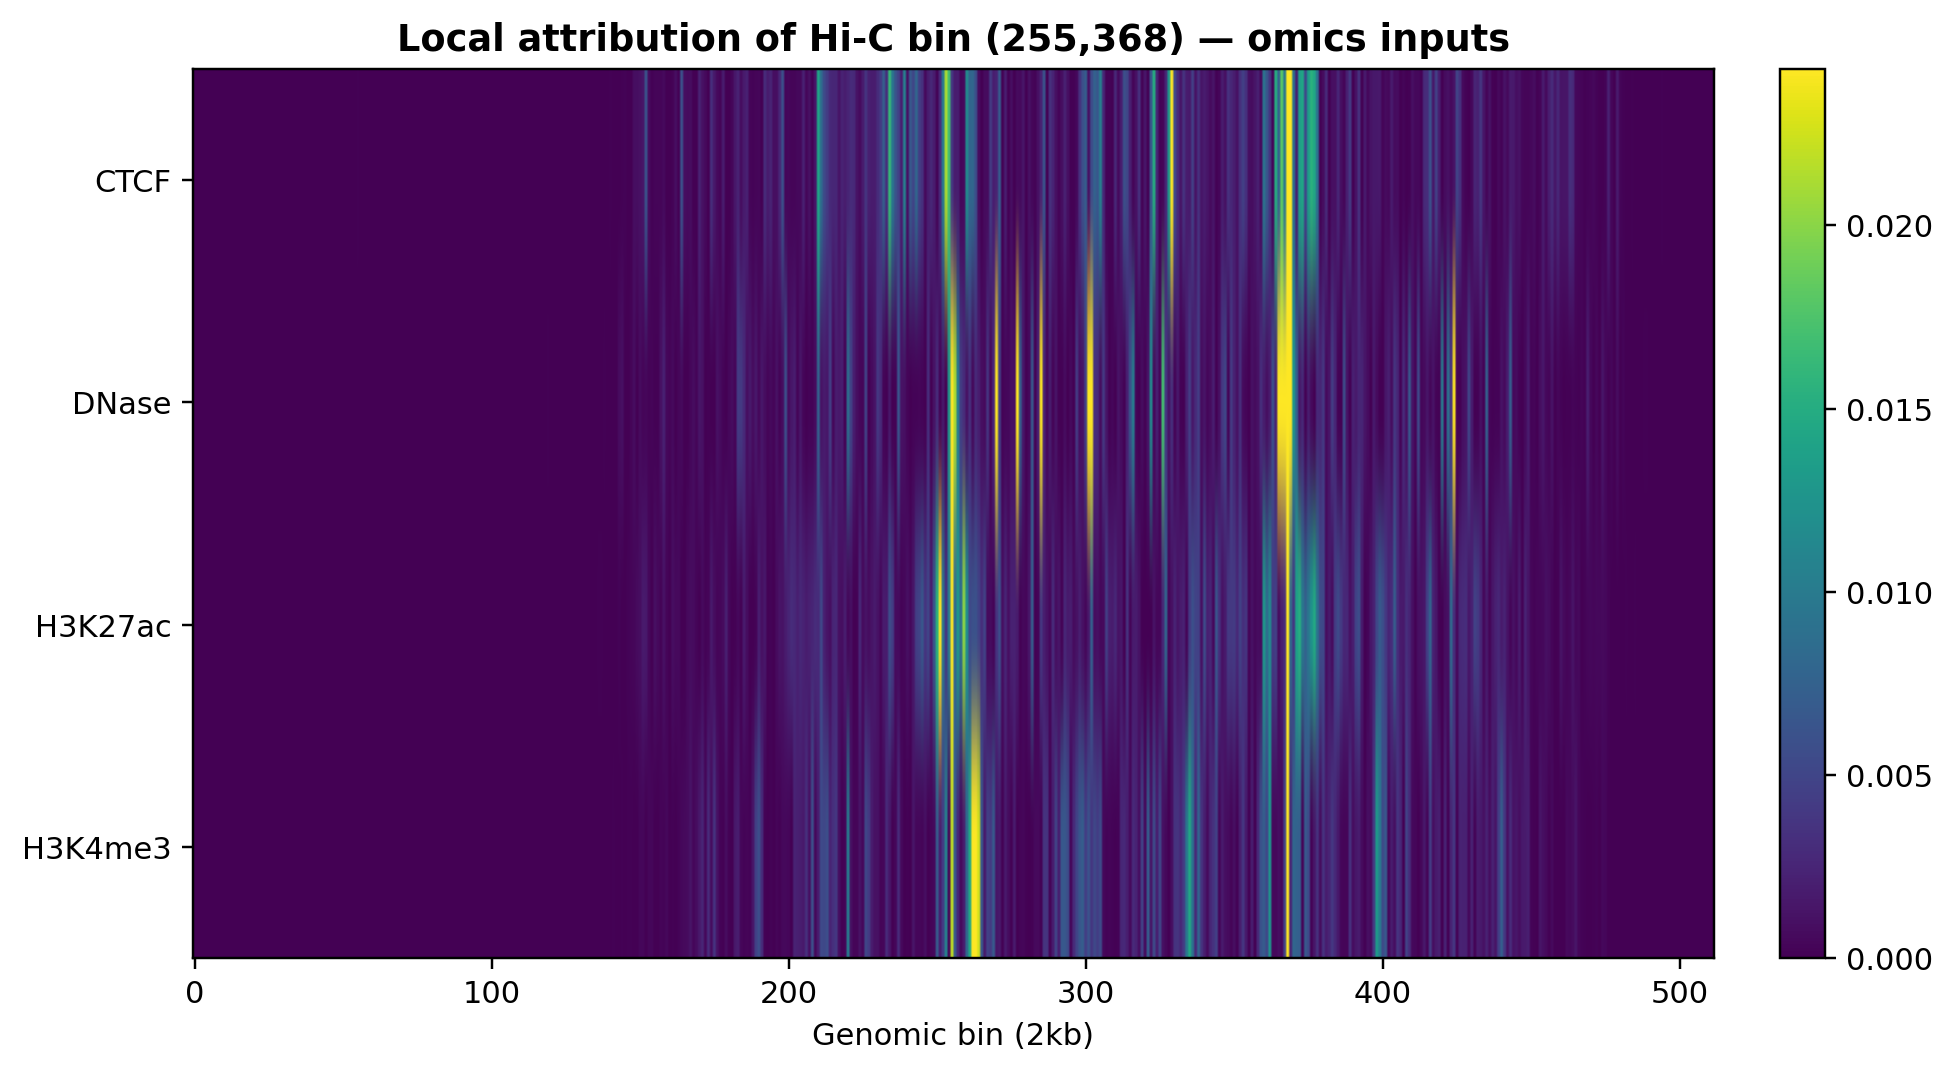

omics attribution (npy): [4, 512], sum=5.773


In [1]:
def step_local_omics():
    all_files = sorted(glob.glob(str(DATA_DIR / '*.pkl')))
    test_files = [f for f in all_files if 'chr7' in os.path.basename(f)]
    LOCAL_FILE = test_files[len(test_files)//2]
    seq, omics, hic = HiCDataAndOmicsDataset([LOCAL_FILE])[0]
    seq_b = seq.unsqueeze(0).to(device)
    omics_b = omics.unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(seq_b, omics_b).squeeze(0).cpu().numpy()

    upper = np.triu(pred, k=50)
    flat_idx = int(np.argmax(upper))
    target_i, target_j = int(flat_idx // pred.shape[1]), int(flat_idx % pred.shape[1])
    print(f'target bin: ({target_i}, {target_j}), predicted value = {pred[target_i, target_j]:.4f}')

    def fwd_omics(omics_in, seq_in):
        return model(seq_in, omics_in)[:, target_i, target_j]

    ig_pixel = IntegratedGradients(fwd_omics)
    attr = ig_pixel.attribute(omics_b, baselines=torch.zeros_like(omics_b),
                              additional_forward_args=(seq_b,), n_steps=50, internal_batch_size=1)
    omics_attr_np = attr.squeeze(0).abs().cpu().numpy()   # (4, 512)
    # vmax clipped at the 99th percentile so outlier bins do not flatten the heatmap into low-value purple
    attr_pos = omics_attr_np[omics_attr_np > 0]
    vmax_attr = float(np.percentile(attr_pos, 99)) if attr_pos.size else 1.0

    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(omics_attr_np, cmap='viridis', aspect='auto', vmin=0, vmax=vmax_attr)
    ax.set_yticks(range(4)); ax.set_yticklabels(OMICS_NAMES)
    ax.set_xlabel('Genomic bin (2kb)')
    ax.set_title(f'Local attribution of Hi-C bin ({target_i},{target_j}) — omics inputs', fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout(); fig.savefig(OUT_DIR / '06_local_attribution_omics.png', dpi=220, bbox_inches='tight'); plt.close(fig)
    # record window and target bin (reused by later steps)
    with open(OUT_DIR / '06_local_target.json', 'w') as fh:
        json.dump({'window': Path(LOCAL_FILE).stem, 'target_i': int(target_i), 'target_j': int(target_j)}, fh)
    print('saved: 06_local_attribution_omics.png')


if not (OUT_DIR / '06_local_attribution_omics.png').exists():
    print('--- step 2a: omics local attribution ---')
    step_local_omics()
else:
    print('omics local attribution artifact exists, skipping (checkpoint)')


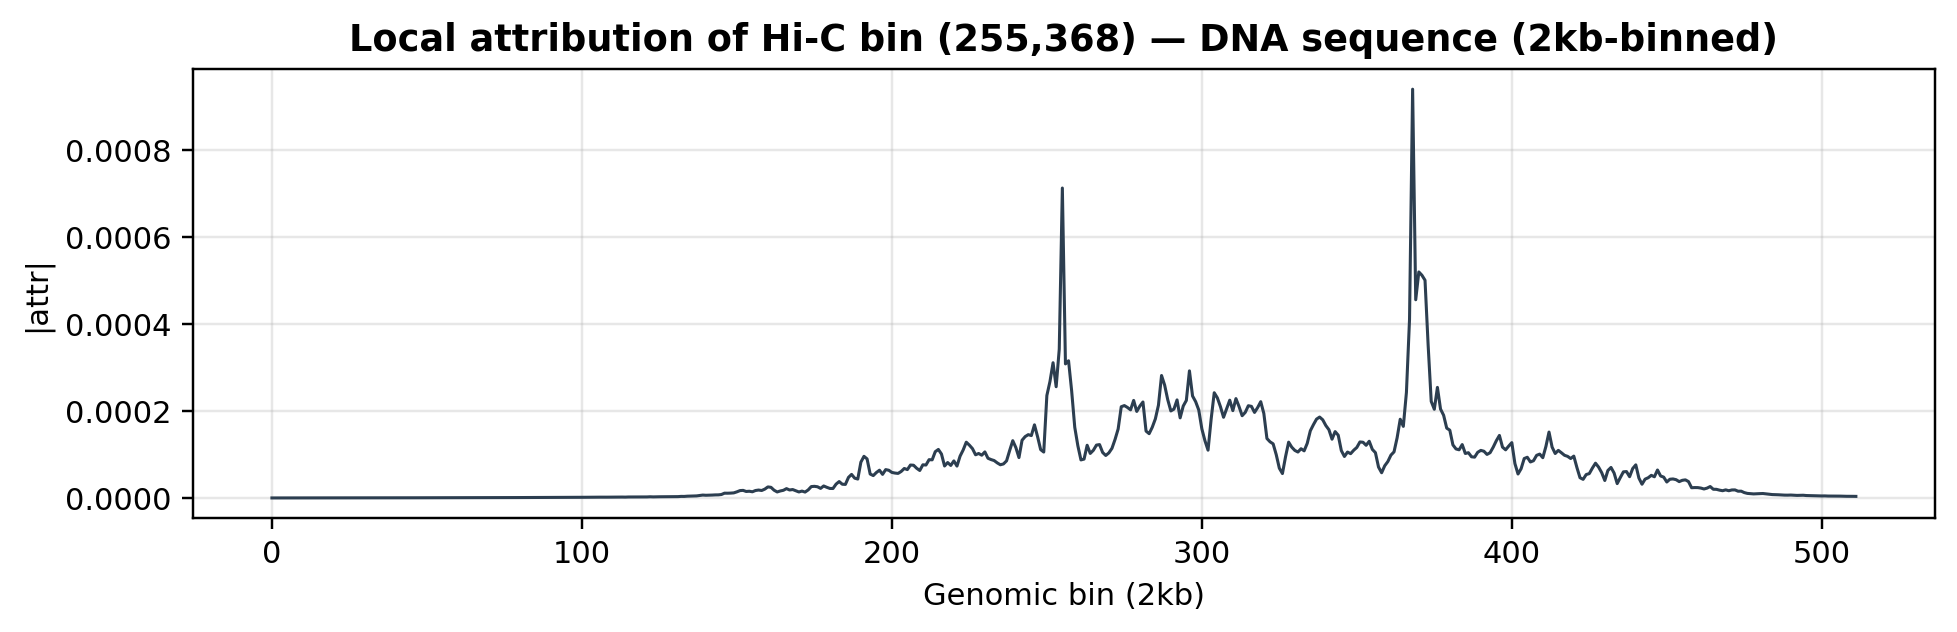

sequence attribution (npy): sum=77.430


In [1]:
def step_seq():
    # read the window and target bin recorded in step 2a
    meta = json.load(open(OUT_DIR / '06_local_target.json'))
    target_i, target_j = meta['target_i'], meta['target_j']
    all_files = sorted(glob.glob(str(DATA_DIR / '*.pkl')))
    test_files = [f for f in all_files if 'chr7' in os.path.basename(f)]
    LOCAL_FILE = str(DATA_DIR / f"{meta['window']}.pkl")
    seq, omics, hic = HiCDataAndOmicsDataset([LOCAL_FILE])[0]

    print('sequence attribution: model moved to CPU, 16 threads, n_steps=50 (expected 60-90 min)...')
    model_cpu = model.cpu()
    torch.set_num_threads(16)

    def fwd_seq_cpu(seq_in, omics_in):
        return model_cpu(seq_in, omics_in)[:, target_i, target_j]

    ig_seq = IntegratedGradients(fwd_seq_cpu)
    seq_c = seq.unsqueeze(0).cpu()
    omics_c = omics.unsqueeze(0).cpu()
    t0 = time.time()
    attr_seq = ig_seq.attribute((seq_c, omics_c),
                                baselines=(torch.zeros_like(seq_c), torch.zeros_like(omics_c)),
                                n_steps=50, internal_batch_size=1)
    print(f'sequence attribution done in {(time.time()-t0)/60:.1f} min')
    seq_attr_np = attr_seq[0].squeeze(0).abs().sum(dim=0).cpu().numpy()
    bin_size = seq_attr_np.shape[0] // 512
    seq_attr_binned = seq_attr_np[:512*bin_size].reshape(512, bin_size).mean(axis=1)
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(seq_attr_binned, color='#2c3e50', lw=1)
    ax.set_xlabel('Genomic bin (2kb)'); ax.set_ylabel('|attr|')
    ax.set_title(f'Local attribution of Hi-C bin ({target_i},{target_j}) — DNA sequence (2kb-binned)', fontweight='bold')
    ax.grid(alpha=0.3)
    fig.tight_layout(); fig.savefig(OUT_DIR / '06_local_attribution_seq.png', dpi=220, bbox_inches='tight'); plt.close(fig)
    print('saved: 06_local_attribution_seq.png')
    model.to(device)   # move back to GPU (for later steps)


if not (OUT_DIR / '06_local_attribution_seq.png').exists():
    print('--- step 2b: sequence local attribution (CPU) ---')
    step_seq()
else:
    print('seq local attribution artifact exists, skipping (checkpoint)')
